<a href="https://colab.research.google.com/github/crystalclcm/Dissertation-Crystal-Matticks/blob/main/02_job_ads_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import pandas as pd

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')


Mounted at /content/drive


['Easilet Lease Control Sheet.xlsx',
 'Easilet Lease Control Sheet.gsheet',
 'Car Spaces  Byrne Moore.xls',
 'Car Spaces  Byrne Moore.gsheet',
 'BW Contact Listing.xlsx',
 'BW Contact Listing.gsheet',
 'RH Customer listing.xlsx',
 'Parking control listing.xlsx',
 'Parking control listing.gsheet',
 'RH Customer listing.gsheet',
 'GLS Customer Listing.xlsx',
 'GLS Customer Listing.gsheet',
 'BM Listing.xlsx',
 'BM Listing.gsheet',
 'GCV Supplier Listing.xlsx',
 'GCV Supplier Listing.gsheet',
 'lease of unit 5, bymac(part 1).pdf',
 '30A BW lease agreement (second half).pdf',
 '30A BW lease agreement (first half).pdf',
 'lease of unit 5, bymac(part 2).pdf',
 '6 ferndale road letter of engagement.pdf',
 '36 st. fintan villas letter of engagement.pdf',
 '36 st. fintan villas lease agreement (part 1).pdf',
 '36 st.fintan villas lease agreement (part 2).pdf',
 '68 st. fintan villas letter of engagement.pdf',
 'index.pdf',
 'Document31 (2).pdf',
 'Document31 (2).gdoc',
 'Colab Notebooks',
 'Unt

In [11]:
pre_ai = pd.read_csv('/content/drive/MyDrive/pre_ai_full.csv')
post_ai = pd.read_csv('/content/drive/MyDrive/adzuna_expanded_combined.csv')
Job_Postings = pd.read_csv('/content/JobPostings.csv')


In [13]:
pre_ai.columns


Index(['job_title', 'job_description', 'country', 'date_posted', 'source',
       'role', 'source_clean', 'skills'],
      dtype='object')

In [14]:
post_ai.columns


Index(['role', 'country', 'job_title', 'company', 'location', 'created',
       'redirect_url', 'description'],
      dtype='object')

In [15]:
Job_Postings.columns


Index(['id', 'title', 'company', 'location', 'salary_min', 'salary_max',
       'created', 'category', 'contract_type', 'contract_time', 'home_url',
       'full_description', 'domain', 'clean_text', 'title_tokens',
       'text_tokens', 'location_tokens', 'title_role', 'family_role',
       'seniority', 'skills_list', 'industry', 'salary_avg'],
      dtype='object')

# standardise and align datasets

In [223]:
import pandas as pd

# -----------------------------
# 1. STANDARDISE PRE-AI DATASET
# -----------------------------
pre_ai_clean = pre_ai.copy()

pre_ai_clean = pre_ai_clean.rename(columns={
    'job_title': 'job_title',
    'job_description': 'raw_text',
    'date_posted': 'date_posted',
    'source_clean': 'source',
    'skills': 'skills_text'
})

# -----------------------------
# 2. STANDARDISE FIRST POST-AI DATASET (Adzuna)
# -----------------------------
post_ai_clean = post_ai.copy()

post_ai_clean = post_ai_clean.rename(columns={
    'job_title': 'job_title',
    'description': 'raw_text',
    'created': 'date_posted',
    'company': 'company',
    'location': 'location',
    'redirect_url': 'redirect_url'
})


# -----------------------------
# 3. STANDARDISE SECOND POST-AI DATASET (Job_Postings)
# -----------------------------
post_ai_extra_clean = Job_Postings.copy()

post_ai_extra_clean = post_ai_extra_clean.rename(columns={
    'title': 'job_title',
    'full_description': 'raw_text',
    'created': 'date_posted',
    'skills_list': 'skills_text',
    'home_url': 'home_url'
})


# -----------------------------
# 4. DEFINE UNIFIED SCHEMA
# -----------------------------
unified_columns = [
    'job_title', 'company', 'location', 'country', 'date_posted', 'role',
    'source', 'industry', 'contract_type', 'contract_time',
    'salary_min', 'salary_max', 'salary_avg',
    'raw_text', 'clean_text', 'skills_text', 'seniority',
    'redirect_url', 'home_url'
]


# -----------------------------
# 5. ADD ANY MISSING COLUMNS TO ALL DATASETS
# -----------------------------
for df in [pre_ai_clean, post_ai_clean, post_ai_extra_clean]:
    for col in unified_columns:
        if col not in df.columns:
            df[col] = None


# -----------------------------
# 6. SELECT COLUMNS IN UNIFIED ORDER
# -----------------------------
pre_ai_clean = pre_ai_clean[unified_columns]
post_ai_clean = post_ai_clean[unified_columns]
post_ai_extra_clean = post_ai_extra_clean[unified_columns]

print("Standardisation complete.")


Standardisation complete.


In [224]:
def basic_clean(text):
    if pd.isna(text):
        return None
    text = str(text)
    text = text.lower()
    text = text.replace("\n", " ")
    text = " ".join(text.split())
    return text

pre_ai_clean["clean_text"] = pre_ai_clean["raw_text"].apply(basic_clean)
post_ai_clean["clean_text"] = post_ai_clean["raw_text"].apply(basic_clean)
post_ai_extra_clean["clean_text"] = post_ai_extra_clean["raw_text"].apply(basic_clean)

print("Basic cleaning done.")


Basic cleaning done.


/tmp/ipykernel_5427/3995996791.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_ai_extra_clean["clean_text"] = post_ai_extra_clean["raw_text"].apply(basic_clean)


In [225]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

german_stopwords = {"der","die","das","des","den","dem","ein","eine","einer","einem","als","und","mit","auf","im","in","am","op","al","er","met"}

stopwords = ENGLISH_STOP_WORDS.union(german_stopwords)

job_ads_clean["clean_text"] = job_ads_clean["clean_text"].apply(
    lambda x: " ".join(
        w for w in x.split()
        if w not in stopwords and len(w) > 2
    )
)


In [226]:
print("PRE-AI duplicates:", pre_ai_clean.columns.duplicated().any())
print("POST-AI duplicates:", post_ai_clean.columns.duplicated().any())
print("EXTRA POST-AI duplicates:", post_ai_extra_clean.columns.duplicated().any())


PRE-AI duplicates: False
POST-AI duplicates: False
EXTRA POST-AI duplicates: False


In [227]:
# Remove duplicate columns from PRE-AI
pre_ai_clean = pre_ai_clean.loc[:, ~pre_ai_clean.columns.duplicated()]
print("PRE-AI duplicate columns removed.")


PRE-AI duplicate columns removed.


In [228]:
# Find columns all datasets share
common_cols = list(
    set(pre_ai_clean.columns) &
    set(post_ai_clean.columns) &
    set(post_ai_extra_clean.columns)
)

print("Number of shared columns:", len(common_cols))
print("Shared columns:", common_cols)


Number of shared columns: 19
Shared columns: ['location', 'salary_avg', 'date_posted', 'contract_time', 'industry', 'redirect_url', 'salary_min', 'job_title', 'skills_text', 'raw_text', 'home_url', 'country', 'clean_text', 'source', 'salary_max', 'role', 'company', 'seniority', 'contract_type']


In [229]:
pre_ai_clean = pre_ai_clean[common_cols]
post_ai_clean = post_ai_clean[common_cols]
post_ai_extra_clean = post_ai_extra_clean[common_cols]

print("Columns aligned.")


Columns aligned.


In [230]:
pre_ai_clean["ai_period"] = "pre_ai"
post_ai_clean["ai_period"] = "post_ai"
post_ai_extra_clean["ai_period"] = "post_ai"


In [231]:
job_ads_clean = pd.concat(
    [pre_ai_clean, post_ai_clean, post_ai_extra_clean],
    ignore_index=True
)


In [232]:
job_ads_clean["ai_period"].value_counts()


,count
ai_period,
post_ai,23527
pre_ai,13036


### Skill extraction and merging

In [233]:
# Simple skill list (can expand this later)
skill_list = [
    "communication",
    "collaboration",
    "teamwork",
    "leadership",
    "analytical",
    "problem solving",
    "python",
    "sql",
    "excel",
    "javascript",
    "java",
    "gcp",
    "sas",
    "agile"
]


In [234]:
def extract_skills(text, skills):
    if pd.isna(text):
        return []

    found = []
    for skill in skills:
        if skill in text:
            found.append(skill)
    return found


In [235]:
job_ads_clean["extracted_skills"] = job_ads_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [236]:
from collections import Counter

all_skills = job_ads_clean["extracted_skills"].sum()
skill_counts = Counter(all_skills)

skill_counts


Counter({'communication': 9087,
         'analytical': 4287,
         'excel': 10655,
         'problem solving': 2817,
         'collaboration': 3112,
         'leadership': 3478,
         'python': 4678,
         'java': 2852,
         'agile': 3197,
         'javascript': 1415,
         'sas': 802,
         'sql': 4826,
         'gcp': 923,
         'teamwork': 957})

In [237]:
skill_counts_df = pd.DataFrame.from_dict(skill_counts, orient='index', columns=['count'])
skill_counts_df.sort_values("count", ascending=False)


,count
excel,10655
communication,9087
sql,4826
python,4678
analytical,4287
leadership,3478
agile,3197
collaboration,3112
java,2852
problem solving,2817


In [238]:
def extract_skills(text, skills):
    if pd.isna(text):
        return []
    found = []
    for skill in skills:
        if skill in text:
            found.append(skill)
    return found


In [239]:
pre_ai_clean["extracted_skills"] = pre_ai_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)

post_ai_clean["extracted_skills"] = post_ai_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)

post_ai_extra_clean["extracted_skills"] = post_ai_extra_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [240]:
job_ads_clean = pd.concat(
    [pre_ai_clean, post_ai_clean, post_ai_extra_clean],
    ignore_index=True
)


In [241]:
job_ads_clean.columns


Index(['location', 'salary_avg', 'date_posted', 'contract_time', 'industry',
       'redirect_url', 'salary_min', 'job_title', 'skills_text', 'raw_text',
       'home_url', 'country', 'clean_text', 'source', 'salary_max', 'role',
       'company', 'seniority', 'contract_type', 'ai_period',
       'extracted_skills'],
      dtype='object')

In [242]:
job_ads_clean["extracted_skills"].head()


,extracted_skills
0,"[communication, analytical, excel]"
1,[excel]
2,"[problem solving, excel]"
3,[excel]
4,"[communication, collaboration, leadership, ana..."


# pre vs post ai skill comparison

In [243]:
pre_ai = job_ads_clean[job_ads_clean["ai_period"] == "pre_ai"]
post_ai = job_ads_clean[job_ads_clean["ai_period"] == "post_ai"]

print("Pre‑AI rows:", len(pre_ai))
print("Post‑AI rows:", len(post_ai))


Pre‑AI rows: 13036
Post‑AI rows: 23527


In [244]:
job_ads_clean.columns


Index(['location', 'salary_avg', 'date_posted', 'contract_time', 'industry',
       'redirect_url', 'salary_min', 'job_title', 'skills_text', 'raw_text',
       'home_url', 'country', 'clean_text', 'source', 'salary_max', 'role',
       'company', 'seniority', 'contract_type', 'ai_period',
       'extracted_skills'],
      dtype='object')

In [245]:
#count sample size
pre_n = len(pre_ai)
post_n = len(post_ai)

print("Pre‑AI sample size:", pre_n)
print("Post‑AI sample size:", post_n)


Pre‑AI sample size: 13036
Post‑AI sample size: 23527


In [246]:
#count skills in each group
from collections import Counter

pre_skill_counts = Counter(pre_ai["extracted_skills"].sum())
post_skill_counts = Counter(post_ai["extracted_skills"].sum())


In [247]:
#build comparison table
import pandas as pd

skill_comparison_norm = pd.DataFrame({
    "pre_ai_raw": pd.Series(pre_skill_counts),
    "post_ai_raw": pd.Series(post_skill_counts)
}).fillna(0)

# Normalise per 1,000 job ads
skill_comparison_norm["pre_ai_per_1000"] = (skill_comparison_norm["pre_ai_raw"] / pre_n) * 1000
skill_comparison_norm["post_ai_per_1000"] = (skill_comparison_norm["post_ai_raw"] / post_n) * 1000

# Difference in normalised values
skill_comparison_norm["difference_per_1000"] = (
    skill_comparison_norm["post_ai_per_1000"] - skill_comparison_norm["pre_ai_per_1000"]
)

skill_comparison_norm.sort_values("difference_per_1000", ascending=False)


,pre_ai_raw,post_ai_raw,pre_ai_per_1000,post_ai_per_1000,difference_per_1000
gcp,367,556,28.152808,23.632422,-4.520385
python,1708,2970,131.021786,126.237939,-4.783846
teamwork,558,399,42.804541,16.959238,-25.845303
sas,504,298,38.662166,12.666298,-25.995868
sql,2060,2766,158.023934,117.567051,-40.456883
collaboration,1603,1509,122.967168,64.139074,-58.828094
problem solving,1571,1246,120.512427,52.960428,-67.551999
analytical,2213,2074,169.760663,88.154036,-81.606627
javascript,1275,140,97.806075,5.950610,-91.855466
leadership,2038,1440,156.336299,61.206274,-95.130026


<Axes: title={'center': 'Top Skills per 1000 Job Ads: Pre‑AI vs Post‑AI'}>

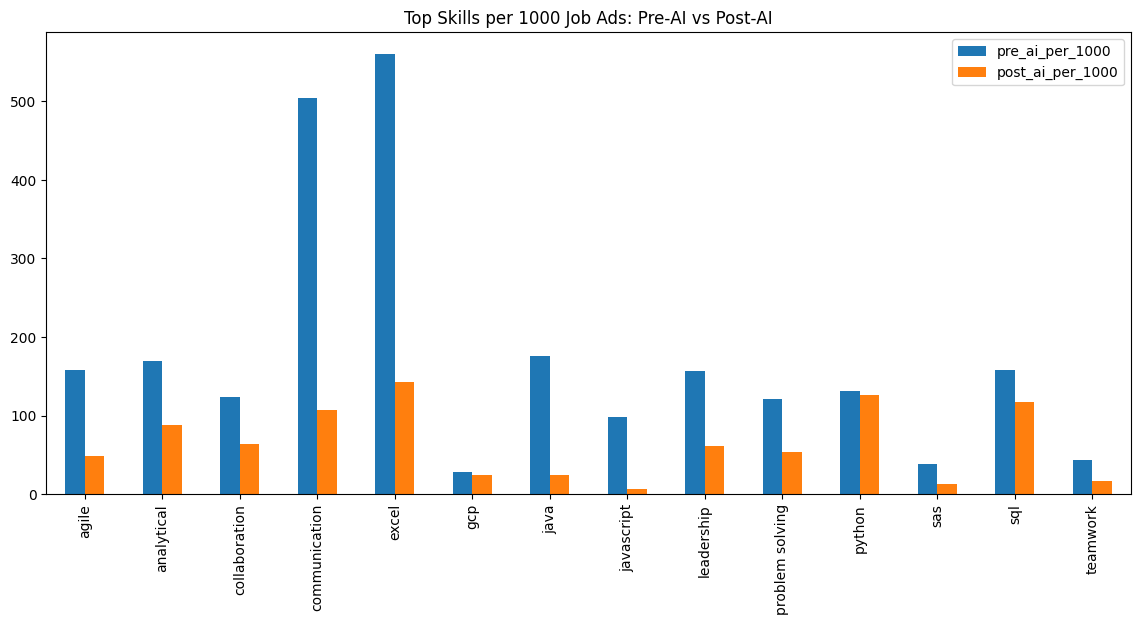

In [248]:
skill_comparison_norm[["pre_ai_per_1000", "post_ai_per_1000"]].plot(
    kind="bar",
    figsize=(14,6),
    title="Top Skills per 1000 Job Ads: Pre‑AI vs Post‑AI"
)


# Build the tfidf model

In [276]:
skill_vocab = [
    "python","sql","cloud","devops","analytics","analysis","engineering",
    "engineer","developer","development","design","security","robotics",
    "medical","device","quality","logistics","cyber","data","process",
    "programming","algorithms","gdpr","iso","fda","automation","testing",
    "validation","verification","manufacturing","biotech","pharma"
]


In [277]:
vectorizer = TfidfVectorizer(
    vocabulary=skill_vocab,
    ngram_range=(1,2)
)

tfidf_matrix = vectorizer.fit_transform(job_ads_clean["clean_text"])
feature_names = vectorizer.get_feature_names_out()

def top_terms_from_vector(row, feature_names, top_n=10):
    indices = row.toarray().flatten().argsort()[-top_n:]
    return [feature_names[i] for i in indices]

job_ads_clean["tfidf_top_terms"] = [
    top_terms_from_vector(tfidf_matrix[i], feature_names)
    for i in range(tfidf_matrix.shape[0])
]


# ESCO skills

In [278]:
esco = pd.read_csv("skills.csv")
esco.head()


,label_cleaned,altLabels
0,manage musical staff,manage staff of music coordinate duties of mus...
1,supervise correctional procedures,oversee prison procedures manage correctional ...
2,apply anti-oppressive practices,apply non-oppressive practices apply an anti-o...
3,control compliance of railway vehicles regulat...,monitoring of compliance with railway vehicles...
4,identify available services,establish available services identify availabl...


In [279]:
esco["label_cleaned"] = esco["label_cleaned"].str.lower().str.strip()


In [280]:
filtered_esco = sorted(esco["label_cleaned"].dropna().unique().tolist())
len(filtered_esco), filtered_esco[:30]


(13893,
 ['3d body scanning technologies',
  '3d lighting',
  '3d modelling',
  '3d printing process',
  '3d texturing',
  '5s methodology',
  'abap',
  'abbyy finereader',
  'abide by business ethical code of conducts',
  'abide by regulations on banned materials',
  'abrasive blasting processes',
  'abrasive machining processes',
  'absorb',
  'accept criticism and guidance',
  'accept feedback on artistic performance',
  'accept own accountability',
  'access to documents regulations',
  'acclimatise timber',
  'accommodate cargo in freight transport vehicle',
  'accommodate special seating',
  'accompany people',
  'accounting',
  'accounting department processes',
  'accounting entries',
  'accounting techniques',
  'accurately estimate work hours',
  'accurise guns',
  'achieve sales targets',
  'acoustical engineering',
  'acoustics'])

In [281]:
esco_list = [
    "personal development",
    "sql server",
    "financial analysis",
    "devops",
    "computer engineering",
    "sql",
    "agile development",
    "cyber security",
    "algorithms",
    "data analytics",
    "electrical engineering",
    "programming",
    "design principles",
    "gdpr",
    "business analysis",
    "civil engineering",
    "robotics",
    "python",
    "mechanical engineering",
    "design process",
    "logistics",
    "medical devices",
    "cloud technologies",
]


In [282]:
job_ads_clean.columns


Index(['location', 'salary_avg', 'date_posted', 'contract_time', 'industry',
       'redirect_url', 'salary_min', 'job_title', 'skills_text', 'raw_text',
       'home_url', 'country', 'clean_text', 'source', 'salary_max', 'role',
       'company', 'seniority', 'contract_type', 'ai_period',
       'extracted_skills', 'tfidf_top_terms', 'esco_skills_cleaned'],
      dtype='object')

In [180]:
!pip install rapidfuzz


In [283]:
from rapidfuzz import fuzz

def fuzzy_align(esco_skill, tfidf_terms, threshold=80):
    for term in tfidf_terms:
        if fuzz.partial_ratio(esco_skill, term) >= threshold:
            return term
    return None


In [284]:
def get_fuzzy_skills(tfidf_terms, esco_list):
    matches = []
    for s in esco_list:
        match = fuzzy_align(s, [t.lower() for t in tfidf_terms])
        if match:
            matches.append(match)
    return matches

job_ads_clean["esco_skills_cleaned"] = job_ads_clean["tfidf_top_terms"].apply(
    lambda terms: get_fuzzy_skills(terms, esco_list)
)




In [286]:
cleaned_esco[:50]


['personal development',
 'sql server',
 'financial analysis',
 'devops',
 'computer engineering',
 'sql',
 'agile development',
 'cyber security',
 'algorithms',
 'data analytics',
 'electrical engineering',
 'programming',
 'design principles',
 'gdpr',
 'business analysis',
 'civil engineering',
 'robotics',
 'python',
 'mechanical engineering',
 'design process',
 'logistics',
 'medical devices',
 'cloud technologies']

In [287]:
esco_list = cleaned_esco


In [289]:
job_ads_clean["tfidf_top_terms"].head(10)


,tfidf_top_terms
0,"[gdpr, iso, verification, manufacturing, testi..."
1,"[iso, fda, pharma, biotech, validation, proces..."
2,"[engineer, analysis, engineering, process, med..."
3,"[iso, fda, pharma, biotech, validation, proces..."
4,"[automation, fda, biotech, pharma, testing, va..."
5,"[automation, fda, biotech, pharma, validation,..."
6,"[manufacturing, device, development, iso, biot..."
7,"[iso, fda, pharma, manufacturing, testing, ver..."
8,"[iso, fda, verification, automation, testing, ..."
9,"[gdpr, iso, verification, automation, testing,..."


In [290]:
job_ads_clean["esco_skills_cleaned"] = job_ads_clean["tfidf_top_terms"].apply(
    lambda terms: get_fuzzy_skills(terms, esco_list)
)


In [294]:
job_ads_clean[["tfidf_top_terms","esco_skills_cleaned"]].head(50)


,tfidf_top_terms,esco_skills_cleaned
0,"[gdpr, iso, verification, manufacturing, testi...","[iso, engineering, engineering, gdpr, iso, eng..."
1,"[iso, fda, pharma, biotech, validation, proces...","[development, iso, development, fda, iso, proc..."
2,"[engineer, analysis, engineering, process, med...","[analysis, engineer, engineer, design, analysi..."
3,"[iso, fda, pharma, biotech, validation, proces...","[development, iso, development, fda, iso, proc..."
4,"[automation, fda, biotech, pharma, testing, va...","[fda, process, medical]"
5,"[automation, fda, biotech, pharma, validation,...","[development, analysis, development, fda, anal..."
6,"[manufacturing, device, development, iso, biot...","[development, iso, engineer, development, engi..."
7,"[iso, fda, pharma, manufacturing, testing, ver...","[iso, engineering, fda, engineering, iso, engi..."
8,"[iso, fda, verification, automation, testing, ...","[iso, fda, iso]"
9,"[gdpr, iso, verification, automation, testing,...","[iso, gdpr, iso, medical]"
